## Option Data Download

In [1]:
# from fetch_option_data import fetch_data_by_month
# fetch_data_by_month("MU", "2016-01-01", "2026-03-15")

## Bcaktesting the Wheel Strategy

In [2]:
from backtest import run_wheel_backtest
from report import WheelPerformanceReport

symbol = "SPY"

result = run_wheel_backtest(
    symbol=symbol,
    start_date="2016-03-15",
    end_date="2026-03-15",
    target_delta=0.2,
    stop_loss_multiple=1.5,
    put_exp_days=12,
    call_exp_days=0,
    initial_cash=5000,
    leverage=10,
)

report = WheelPerformanceReport(result)

In [3]:
report.summary_table()

,Value
Metric,
Symbol,SPY
Start Date,2016-03-15
End Date,2026-03-13
Initial Cash,"$5,000.00"
Ending Equity,"$23,205.42"
Net Profit,"$18,205.42"
Cash Interest Earned,"$3,039.92"
Total Return,364.11%
CAGR,16.60%


In [4]:
report.trade_breakdown_table()

,legs,total_premium,avg_premium,avg_roi,avg_iv,avg_abs_delta,avg_moneyness,avg_days_held
type,,,,,,,,
put,379,"$63,549.00",$167.68,0.12%,19.73%,0.20,-2.96%,8.30


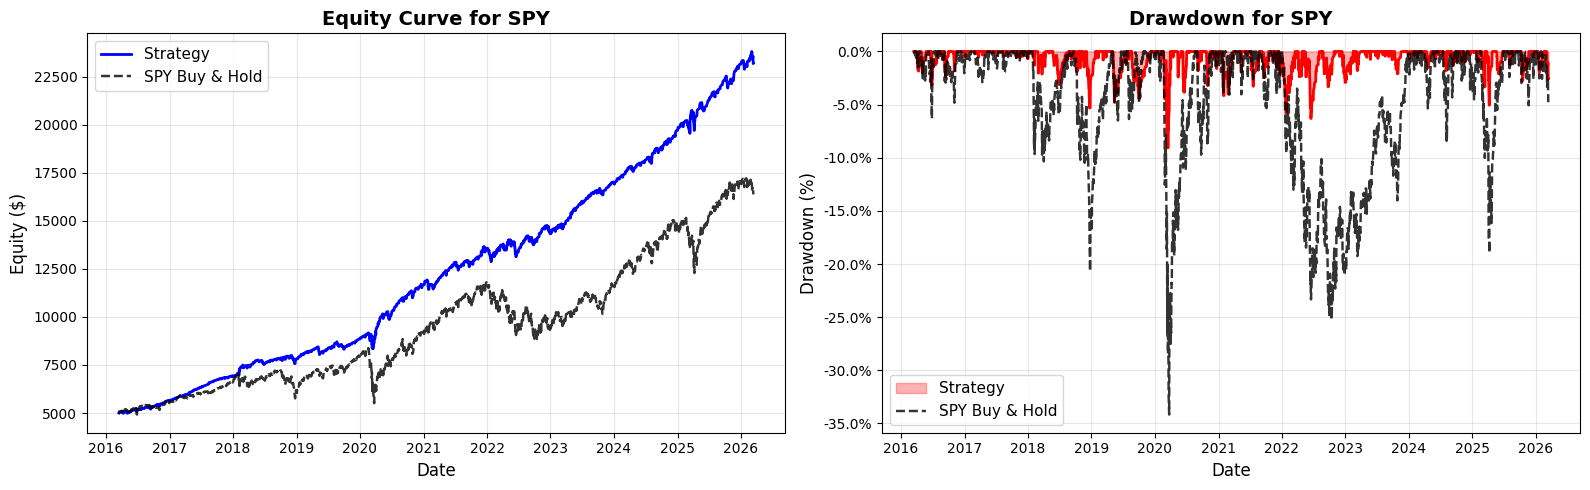

In [5]:
_ = report.plot_equity_and_drawdown()

In [6]:
from IPython.display import HTML, display

def display_long_df(df, max_height=400, max_width='100%'):
    html = (
        f"<div style='max-height:{max_height}px; overflow:auto; width:{max_width}; padding:5px;'>"
        f"{df.to_html(escape=False, index=False)}"
        f"</div>"
    )
    display(HTML(html))

display_long_df(result.trades)

date,side,type,strike,expiration,premium_per_share,premium,delta,leverage_ratio,moneyness,iv,outcome,days_held,ROI%,cash_flow,liquidation_cost,nav,exec_spot,spot,buyback_price_per_share,stop_trigger_price_per_share,stop_open_price_per_share
2016-03-15,short,put,195.0,2016-03-31,0.810,81.000000,-0.193621,3.900000,-3.546520,0.175310,expired,16,0.415385,81.000000,NaN,5081.521028,202.170,205.780,NaN,NaN,NaN
2016-04-01,short,put,202.5,2016-04-15,0.540,53.999996,-0.188099,3.984996,-2.159733,0.127121,cut_loss,4,-0.266667,-54.000004,NaN,5027.640129,206.970,204.350,1.0800,1.30,1.08
2016-04-06,short,put,201.5,2016-04-22,0.680,68.000000,-0.198329,4.007813,-2.397675,0.140082,cut_loss,1,-0.168734,-34.000000,NaN,4993.718666,206.450,203.920,1.0200,1.80,0.96
2016-04-08,short,put,199.5,2016-04-22,0.705,70.500004,-0.200875,3.994988,-2.444988,0.154149,expired,14,0.353383,70.500004,NaN,5064.640056,204.500,208.957,NaN,NaN,NaN
2016-04-25,short,put,203.0,2016-05-13,0.735,73.500000,-0.193954,4.008148,-2.672433,0.145165,cut_loss,4,-0.184729,-37.500000,NaN,5027.342213,208.574,206.510,1.1100,1.68,1.11
2016-05-02,short,put,202.0,2016-05-20,0.815,81.500000,-0.197991,4.017998,-2.842576,0.157100,cut_loss,1,-0.201733,-40.750000,NaN,4986.665707,207.910,206.150,1.2225,1.50,1.17
2016-05-04,short,put,199.0,2016-05-20,0.805,80.500000,-0.192317,3.990617,-3.021442,0.172892,expired,16,0.404523,80.500000,NaN,5067.742918,205.200,205.570,NaN,NaN,NaN
2016-05-23,short,put,199.5,2016-06-10,0.800,80.000000,-0.202045,3.936617,-2.706657,0.152535,expired,18,0.401003,80.000000,NaN,5148.473022,205.050,210.150,NaN,NaN,NaN
2016-06-13,short,put,199.0,2016-06-30,1.335,133.500000,-0.208445,3.865189,-4.524301,0.244457,cut_loss,14,-0.335427,-66.750000,NaN,5082.258097,208.430,198.940,2.0025,2.74,1.68
2016-06-28,short,put,196.5,2016-07-15,0.995,99.500000,-0.203004,3.866358,-3.335301,0.195324,expired,17,0.506361,99.500000,NaN,5182.409198,203.280,215.640,NaN,NaN,NaN


## Grid Search for Hyperparameter Optimization

In [7]:
import pandas as pd
from grid_search import run_grid_search

# grid_results = run_grid_search(
#     symbol=symbol,
#     start_date="2016-03-15",
#     end_date="2026-03-15",
#     initial_cash=8_000,
#     leverage=10,
#     max_workers=5,
# )

In [12]:
grid_results = pd.read_csv("data/grid_search/grid_results.csv")
filtered_results = grid_results[grid_results["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.2, stop=1.5, put_dte=12",0.112261,1.709035,-0.070802
"delta=0.25, stop=1.5, put_dte=12",0.120992,1.542483,-0.114862
"delta=0.25, stop=1.5, put_dte=10",0.102522,1.352223,-0.131276
"delta=0.15, stop=4.0, put_dte=12",0.102829,1.301898,-0.152358
"delta=0.3, stop=1.5, put_dte=12",0.119231,1.225713,-0.204642
"delta=0.3, stop=3.0, put_dte=12",0.135269,1.122280,-0.179701
"delta=0.3, stop=1, put_dte=12",0.100072,1.116327,-0.223785
"delta=0.25, stop=2.5, put_dte=12",0.114188,1.101275,-0.251513
"delta=0.25, stop=3.0, put_dte=12",0.118837,1.085487,-0.285436
"delta=0.25, stop=2.0, put_dte=14",0.110380,1.075086,-0.196820


In [9]:
# grid_results_qqq = run_grid_search(
#     symbol="QQQ",
#     start_date="2016-03-15",
#     end_date="2026-03-15",
#     initial_cash=8_000,
#     leverage=10,
#     max_workers=5,
# )

In [10]:
grid_results_qqq = pd.read_csv("data/grid_search/grid_results_qqq.csv")
display_long_df(grid_results_qqq[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.1, stop=2.0, put_dte=3",0.066799,1.595678,-0.083482
"delta=0.1, stop=1, put_dte=3",0.059632,1.545383,-0.081437
"delta=0.1, stop=1.5, put_dte=3",0.057054,1.393252,-0.109120
"delta=0.2, stop=1.5, put_dte=10",0.093435,1.317946,-0.092965
"delta=0.2, stop=1, put_dte=10",0.082434,1.282008,-0.121029
"delta=0.15, stop=1.5, put_dte=3",0.074241,1.276847,-0.130227
"delta=0.25, stop=1, put_dte=10",0.097165,1.270579,-0.197436
"delta=0.1, stop=3.0, put_dte=3",0.066298,1.261268,-0.095013
"delta=0.15, stop=1, put_dte=10",0.071982,1.236549,-0.112472
"delta=0.1, stop=1.5, put_dte=12",0.064622,1.228882,-0.098153


In [11]:
from pathlib import Path

data_dir = Path("data/grid_search")
data_dir.mkdir(parents=True, exist_ok=True)

grid_results.to_csv(data_dir / "grid_results.csv", index=False)
grid_results_qqq.to_csv(data_dir / "grid_results_qqq.csv", index=False)